# Galapagos Islands Species Diversity Analysis

**Objective:** Build and evaluate a Multiple Linear Regression model to identify key ecological factors that influence plant species richness across the Galapagos Islands. 

As data scientists, understanding which variables drive a target outcome allows us to build predictive models and inform strategic decision-making. In this analysis, we will:
1. Assess the relationship between island **Area**, **Elevation**, and **Nearest** distance on **Species** count.
2. Evaluate model assumptions (multicollinearity, homoscedasticity, normality).
3. Validate predictive performance against a baseline model.

In [2]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from faraway.datasets import galapagos
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set visual theme
sns.set_theme(style="whitegrid")

## 1. Data Ingestion & Preparation
We load the dataset from the `faraway` package. To prepare the data for the `statsmodels` OLS function, we separate our predictors ($X$) from our target variable ($y$) and add a constant (intercept) to the predictor matrix.

In [3]:
# Load dataset
data = galapagos.load()

# Define predictors and response
X_predictors = data[['Area', 'Elevation', 'Nearest']]
X = sm.add_constant(X_predictors)
y = data['Species']

# Inspect the first few rows
data.head()

,Species,Area,Elevation,Nearest,Scruz,Adjacent
Baltra,58,25.09,346,0.6,0.6,1.84
Bartolome,31,1.24,109,0.6,26.3,572.33
Caldwell,3,0.21,114,2.8,58.7,0.78
Champion,25,0.10,46,1.9,47.4,0.18
Coamano,2,0.05,77,1.9,1.9,903.82


## 2. Multicollinearity Check
Before fitting the model, we must ensure our independent variables are not highly correlated with each other. High multicollinearity inflates standard errors and makes coefficient estimates unstable. We assess this using the Correlation Matrix and Variance Inflation Factors (VIF). A VIF below 5 is generally acceptable.

Variance Inflation Factors
     Feature       VIF
0       Area  2.397088
1  Elevation  2.781468
2    Nearest  1.291843


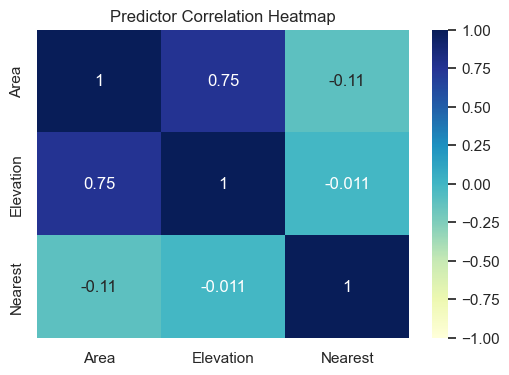

In [4]:
# Calculate Variance Inflation Factors
vif_df = pd.DataFrame({
    'Feature': X_predictors.columns,
    'VIF': [variance_inflation_factor(X_predictors.values, i) for i in range(X_predictors.shape[1])]
})
print("Variance Inflation Factors")
print(vif_df)

# Plot Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(X_predictors.corr(), annot=True, cmap='YlGnBu', vmin=-1, vmax=1)
plt.title("Predictor Correlation Heatmap")
plt.show()

## 3. Model Fitting
We fit an Ordinary Least Squares (OLS) Multiple Linear Regression model. The summary output provides the coefficients, $R^2$ values, and p-values required to determine which variables hold statistical significance.

In [4]:
# Fit the Multiple Linear Regression model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Species   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     10.77
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           8.82e-05
Time:                        13:30:36   Log-Likelihood:                -172.20
No. Observations:                  30   AIC:                             352.4
Df Residuals:                      26   BIC:                             358.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.4647     23.389      0.704      0.4

## 4. Residual Diagnostics
A valid linear regression model assumes that the residuals (errors) are normally distributed and exhibit constant variance (homoscedasticity). We visualize these assumptions using diagnostic plots and formally test for normality using the Shapiro-Wilk test.

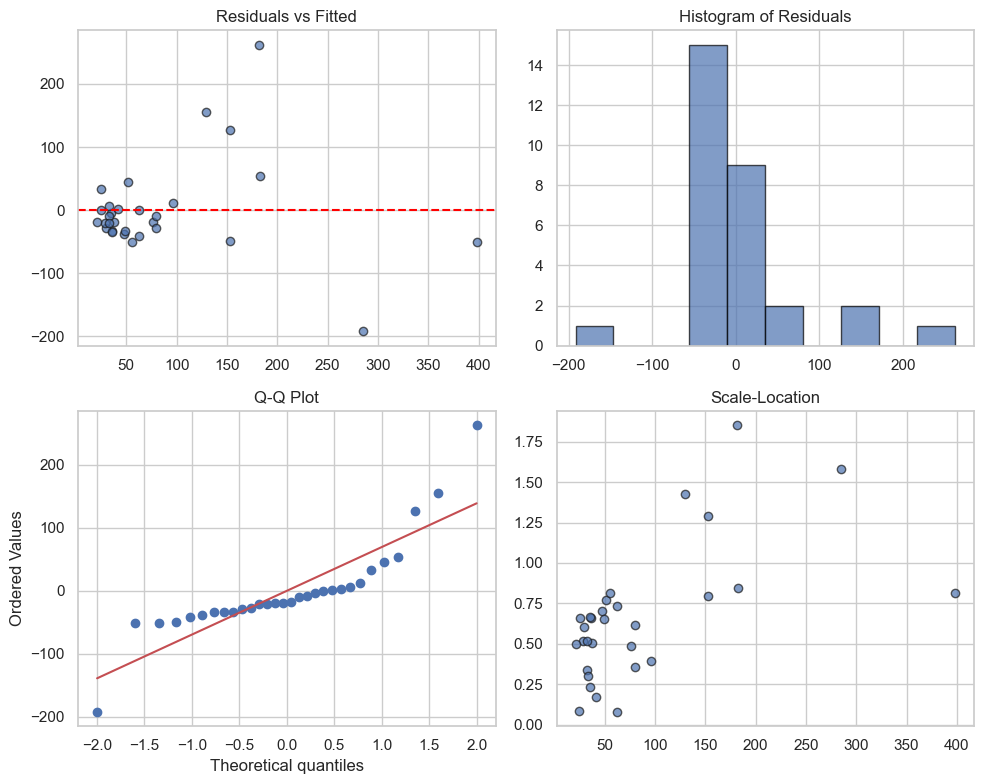

Shapiro-Wilk Test: Statistic=0.7938, p-value=0.0001


In [5]:
residuals = model.resid
fitted_vals = model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Residuals vs Fitted
axes[0, 0].scatter(fitted_vals, residuals, alpha=0.7, edgecolors='k')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted')

# 2. Histogram of Residuals
axes[0, 1].hist(residuals, bins=10, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Histogram of Residuals')

# 3. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# 4. Scale-Location
axes[1, 1].scatter(fitted_vals, np.sqrt(np.abs(residuals / residuals.std())), alpha=0.7, edgecolors='k')
axes[1, 1].set_title('Scale-Location')

plt.tight_layout()
plt.show()

# Formal Normality Test
stat, p_val = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: Statistic={stat:.4f}, p-value={p_val:.4f}")

## 5. Model Validation & Comparison
To test the model's robustness, we apply 5-fold cross-validation. We also compare our full model against a simple baseline model (using only `Area`) to quantify the exact predictive lift provided by adding `Elevation` and `Nearest`.

In [6]:
# 5-Fold Cross Validation
cv_scores = cross_val_score(LinearRegression(), X_predictors, y, cv=5, scoring='r2')
print(f"5-Fold CV R²: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Baseline Comparison
model_simple = sm.OLS(y, sm.add_constant(data[['Area']])).fit()
print(f"Simple Model (Area only) R²: {model_simple.rsquared:.4f}")
print(f"Full Model R²:               {model.rsquared:.4f}")

5-Fold CV R²: -8.1992 (±10.4629)
Simple Model (Area only) R²: 0.3817
Full Model R²:               0.5541


## 6. Scenario Prediction
We can now deploy the fitted model to make predictions. Here, we estimate the species count for a hypothetical new island, generating both a point estimate and the 95% confidence/prediction intervals.

In [8]:
# Define hypothetical island metrics
new_island = pd.DataFrame({'const': [1.0], 'Area': [10.0], 'Elevation': [100.0], 'Nearest': [1.5]})

# Generate predictions and intervals
pred_frame = model.get_prediction(new_island).summary_frame(alpha=0.05)
print("Prediction for New Island (Area=10, Elevation=100, Nearest=1.5)")
print(pred_frame[['mean', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper']])

Prediction for New Island (Area=10, Elevation=100, Nearest=1.5)
        mean  mean_ci_lower  mean_ci_upper  obs_ci_lower  obs_ci_upper
0  33.896026      -7.230856      75.022908   -137.289099    205.081151


## 7. Key Findings & Strategic Takeaways

1. **Primary Driver:** Elevation is the only statistically significant predictor ($p < 0.05$) in this model. Higher islands support a wider variety of plant species.
2. **Model Performance:** The full model explains approximately 55.4% of the variance in species richness. It successfully outperforms a simple `Area`-only baseline.
3. **Assumptions Violation:** The residual diagnostics and Shapiro-Wilk test indicate right-skewness and heteroscedasticity. 
4. **Next Steps for V2:** To resolve the heteroscedasticity and improve prediction accuracy, a log-transformation of the response variable (`Species`) and predictors (`Area`) should be implemented in the next iteration of this pipeline.